<a href="https://colab.research.google.com/github/SasanduG/Image-Processing-Assignment-1/blob/main/Assignment_1_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [8]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# OpenCV reads as BGR
img_bgr = cv2.imread(filename)

# Convert to RGB for displaying
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

Saving WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg to WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg


In [9]:
# Convert RGB image to Lab
lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

# Separate L, a, b channels
L, a, b = cv2.split(lab)

# Gamma value
gamma = 0.6

# Normalize L to [0, 1]
L_norm = L.astype(np.float32) / 255.0

# Gamma correction
L_corrected_norm = L_norm ** gamma

# Convert back to [0, 255]
L_corrected = np.uint8(
    np.clip(L_corrected_norm * 255, 0, 255)
)

# Combine corrected L with original a and b
lab_corrected = cv2.merge([
    L_corrected,
    a,
    b
])

# Convert back to RGB
corrected_rgb = cv2.cvtColor(
    lab_corrected,
    cv2.COLOR_LAB2RGB
)

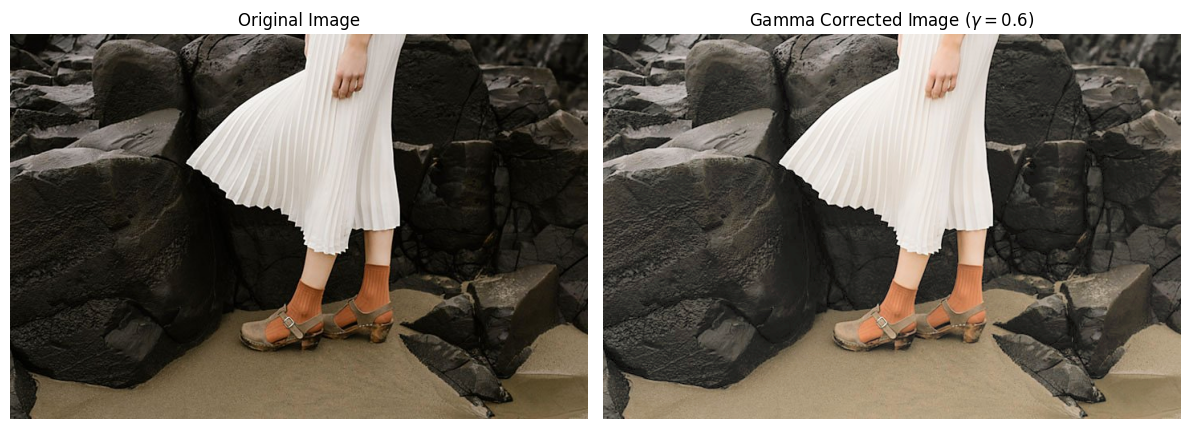

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(corrected_rgb)
plt.title(r"Gamma Corrected Image ($\gamma=0.6$)")
plt.axis("off")

plt.tight_layout()
plt.show()

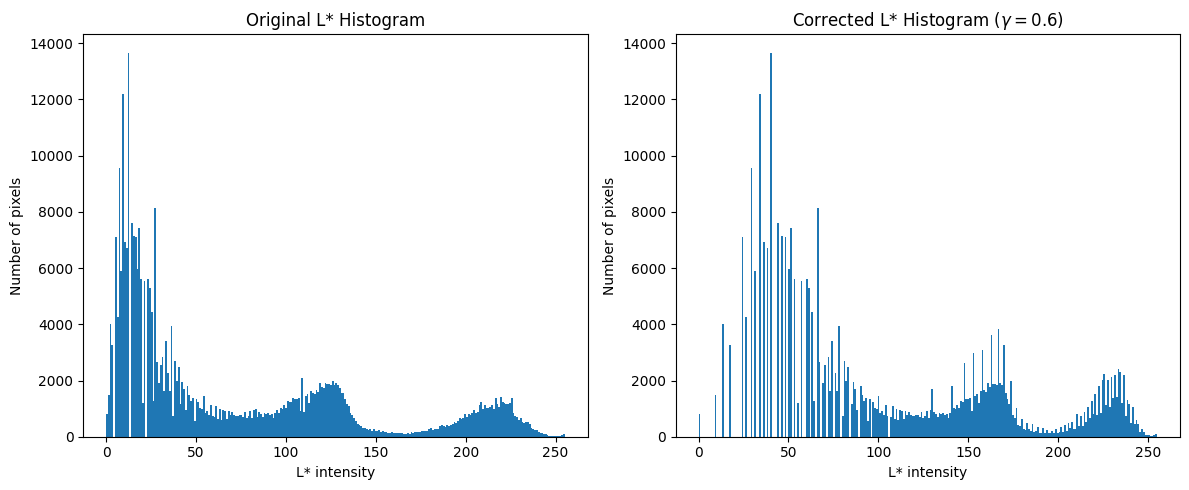

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(
    L.ravel(),
    bins=256,
    range=(0, 255)
)

plt.xlabel("L* intensity")
plt.ylabel("Number of pixels")
plt.title("Original L* Histogram")


plt.subplot(1, 2, 2)

plt.hist(
    L_corrected.ravel(),
    bins=256,
    range=(0, 255)
)

plt.xlabel("L* intensity")
plt.ylabel("Number of pixels")
plt.title(r"Corrected L* Histogram ($\gamma=0.6$)")

plt.tight_layout()
plt.show()